Total Agentes: 1000
Uso de Coche: 401 (40.1%)
Uso de Bus: 599 (59.9%)


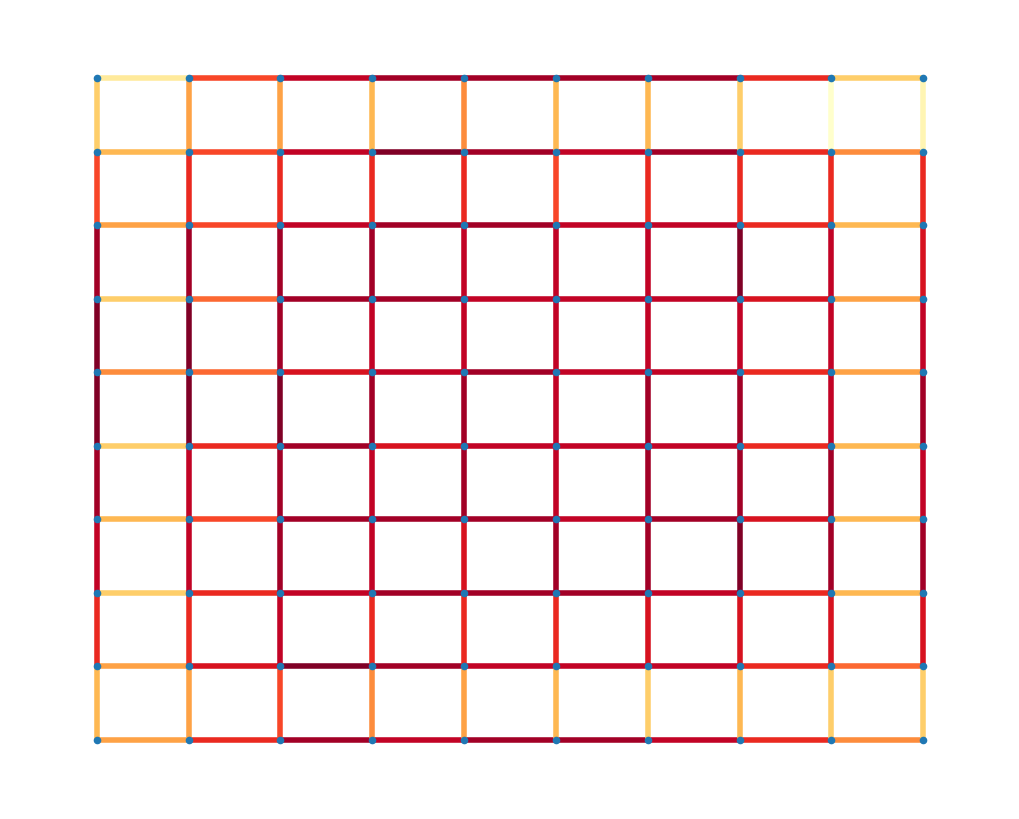

<class 'ValueError'>: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

In [8]:
import networkx as nx
import random
import matplotlib.pyplot as plt

#1.Entorno
N = 10
G = nx.grid_2d_graph(N, N)

#calles (grid)
for u, v in G.edges():
    G[u][v]['cars_count'] = 0

#2.Creación de los Agentes (10 por cada uno de los 100 nodos)
agentes = []
nodos = list(G.nodes())
personas_por_nodo = 10

for nodo_origen in nodos:
    for i in range(personas_por_nodo):
        #el destino es aleatorio distinto al origen
        destino = random.choice(nodos)
        while destino == nodo_origen:
            destino = random.choice(nodos)
        
        agentes.append({
            'origen': nodo_origen,
            'destino': destino,
            'modo': None,
            'tiempo_final': 0
        })

#3.Función de Congestión Realista (BPR)
def get_coste_carretera(coches):
    tiempo_base = 5
    capacidad = 8 #Número de coches que pueden circular por la calle
    #Si hay mas coches que capacidad, el tiempo sube exponencialmente
    return tiempo_base * (1 + 0.15 * (coches / capacidad)**4)

#4.Simulación 
#Mezclamos los agentes para que no salgan todos los de un mismo nodo a la vez
random.shuffle(agentes)

for a in agentes:
    #Ruta más corta por carretera con tráfico actual
    ruta = nx.shortest_path(G, a['origen'], a['destino'], 
                            weight=lambda u, v, d: get_coste_carretera(d['cars_count']))
    
    coste_coche = sum([get_coste_carretera(G[u][v]['cars_count']) 
                       for u, v in zip(ruta[:-1], ruta[1:])])
    
    #Coste Bus:10 min fijos por tramo (ruta geográfica más corta)
    coste_bus = nx.shortest_path_length(G, a['origen'], a['destino']) * 10
    
    if coste_coche <= coste_bus:
        a['modo'] = 'coche'
        a['tiempo_final'] = coste_coche
        #El agente ocupa la calles
        for i in range(len(ruta)-1):
            G[ruta[i]][ruta[i+1]]['cars_count'] += 1
    else:
        a['modo'] = 'bus'
        a['tiempo_final'] = coste_bus

#5. Visualización de Resultados
coches_total = len([a for a in agentes if a['modo'] == 'coche'])
buses_total = len([a for a in agentes if a['modo'] == 'bus'])

print(f"Total Agentes: {len(agentes)}")
print(f"Uso de Coche: {coches_total} ({coches_total/10:.1f}%)")
print(f"Uso de Bus: {buses_total} ({buses_total/10:.1f}%)")

#Dibujar el mapa de calor de tráfico
edges, weights = zip(*nx.get_edge_attributes(G, 'cars_count').items())

plt.figure(figsize=(10, 8))
pos = {node: node for node in G.nodes()} #Posición en grid
nx.draw(G, pos, node_size=20, edge_color=weights, edge_cmap=plt.cm.YlOrRd, 
        width=4, with_labels=False)
plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd), label='Número de Coches')
plt.title("Congestión en el Grid (10 personas por nodo)")
plt.show()

In [1]:
!pip install networkx

mambajs 0.19.13

Process pip requirements ...



Día 1: Coche = 378 | Bus = 622
Día 2: Coche = 49 | Bus = 951
Día 3: Coche = 848 | Bus = 152
Día 4: Coche = 174 | Bus = 826
Día 5: Coche = 21 | Bus = 979
Día 6: Coche = 971 | Bus = 29
Día 7: Coche = 275 | Bus = 725


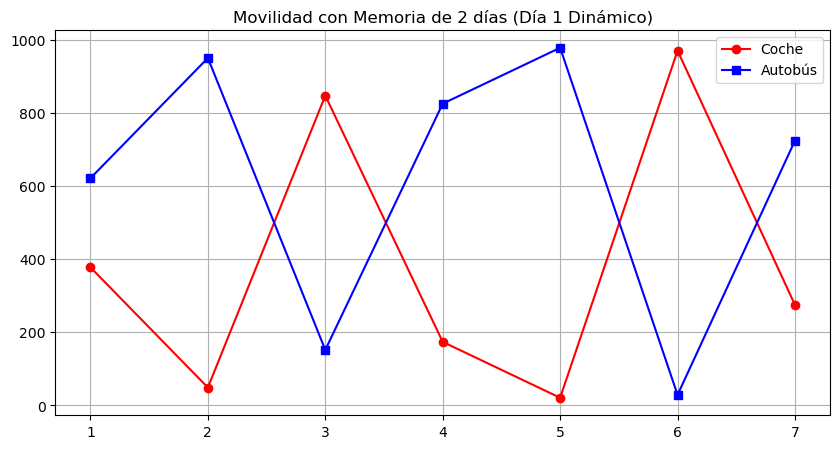

In [3]:
import networkx as nx
import random
import matplotlib.pyplot as plt

#Configuración del grid
N=10
G=nx.grid_2d_graph(N, N)
COSTE_BUS_TRAMO=10 #fixed

for u, v in G.edges():
    G[u][v]['historial']=[] #historico de costes para poder tomar decisiones 

#Agentes (1000 agentes con O-D fijos durante la semana)
agentes=[]
nodos=list(G.nodes())
for nodo_origen in nodos:
    for i in range(10):
        destino=random.choice(nodos)
        while destino==nodo_origen:
            destino=random.choice(nodos)
        agentes.append({'origen':nodo_origen,'destino':destino})

def get_coste_bpr(coches):
    return 5*(1+0.15*(coches/8)**4) #formula de congestion de la ruta desarrollada por la Bureau of Public Roads

#Simulación (7 días)
dias=7
historico_coches=[]
historico_buses=[]

for dia in range(1,dias+1):
    for u, v in G.edges():
        G[u][v]['cars_count_hoy']=0

    random.shuffle(agentes)
    conteo_coche, conteo_bus=0,0
    
    for a in agentes:
        #--- LÓGICA DE LA MEMORIA ---
        if dia==1:
            #Día 1:Información en tiempo real
            ruta=nx.shortest_path(G, a['origen'], a['destino'], 
                                    weight=lambda u, v, d: get_coste_bpr(d['cars_count_hoy']))
            coste_coche_percibido=sum([get_coste_bpr(G[u][v]['cars_count_hoy']) 
                                         for u, v in zip(ruta[:-1], ruta[1:])])
        else:
            #Días siguientes:mirar historial
            def peso_memoria(u, v, d):
                hist=d['historial']
                if len(hist)==1:
                    return hist[-1] #Solo hay un día previo
                else:
                    return (hist[-1]+hist[-2])/2 #Promedio de los últimos 2 días

            ruta=nx.shortest_path(G, a['origen'], a['destino'], weight=peso_memoria)
            coste_coche_percibido=sum([peso_memoria(u, v, G[u][v]) 
                                         for u, v in zip(ruta[:-1], ruta[1:])])

        #Coste bus fijo: 10 min por tramo
        distancia=nx.shortest_path_length(G, a['origen'],a['destino'])
        coste_bus=distancia*COSTE_BUS_TRAMO
        
        if coste_coche_percibido<=coste_bus:
            a['modo']='coche'
            conteo_coche+=1
            for i in range(len(ruta)-1):
                G[ruta[i]][ruta[i+1]]['cars_count_hoy']+=1
        else:
            a['modo']='bus'
            conteo_bus+=1

    #FIN DEL DÍA: Guardar el coste real en el historial de cada calle 
    for u, v in G.edges():
        coste_real_hoy=get_coste_bpr(G[u][v]['cars_count_hoy'])
        G[u][v]['historial'].append(coste_real_hoy)

    historico_coches.append(conteo_coche)
    historico_buses.append(conteo_bus)
    print(f"Día {dia}: Coche = {conteo_coche} | Bus = {conteo_bus}")

# 4. Gráfico
plt.figure(figsize=(10,5))
plt.plot(range(1,dias+1),historico_coches,label="Coche",color='red',marker='o')
plt.plot(range(1, dias + 1), historico_buses,label="Autobús",color='blue',marker='s')
plt.title("Movilidad con Memoria de 2 días (Día 1 Dinámico)")
plt.legend()
plt.grid(True)
plt.show()

Día 1: Coche = 392 | Bus = 608
Día 2: Coche = 47 | Bus = 953
Día 3: Coche = 997 | Bus = 3
Día 4: Coche = 75 | Bus = 925
Día 5: Coche = 62 | Bus = 938
Día 6: Coche = 91 | Bus = 909
Día 7: Coche = 106 | Bus = 894
Día 8: Coche = 104 | Bus = 896
Día 9: Coche = 162 | Bus = 838
Día 10: Coche = 185 | Bus = 815
Día 11: Coche = 972 | Bus = 28
Día 12: Coche = 12 | Bus = 988
Día 13: Coche = 24 | Bus = 976
Día 14: Coche = 49 | Bus = 951
Día 15: Coche = 86 | Bus = 914
Día 16: Coche = 196 | Bus = 804
Día 17: Coche = 99 | Bus = 901
Día 18: Coche = 211 | Bus = 789
Día 19: Coche = 955 | Bus = 45
Día 20: Coche = 10 | Bus = 990
Día 21: Coche = 28 | Bus = 972
Día 22: Coche = 35 | Bus = 965
Día 23: Coche = 76 | Bus = 924
Día 24: Coche = 292 | Bus = 708
Día 25: Coche = 17 | Bus = 983
Día 26: Coche = 233 | Bus = 767
Día 27: Coche = 915 | Bus = 85
Día 28: Coche = 10 | Bus = 990
Día 29: Coche = 22 | Bus = 978
Día 30: Coche = 39 | Bus = 961


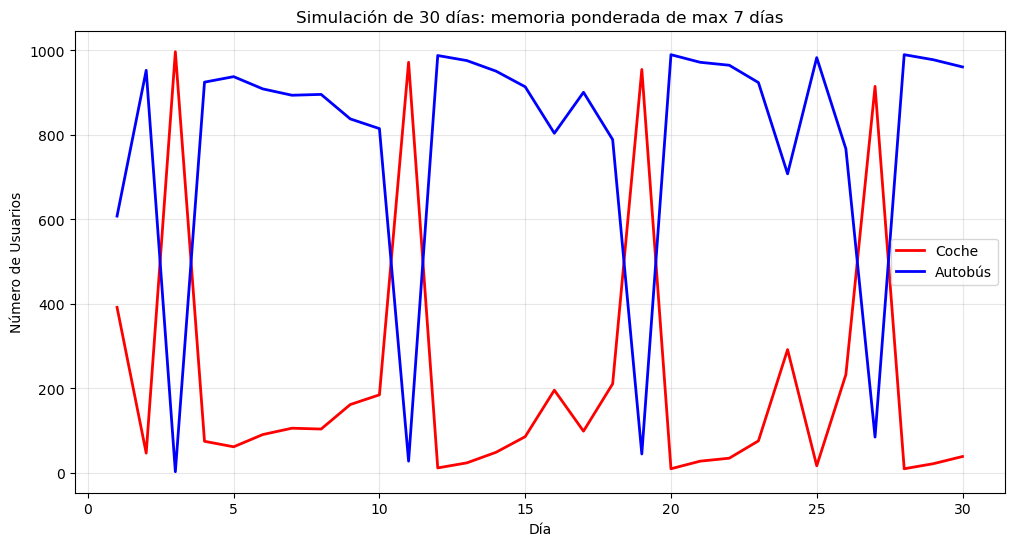

In [4]:
import networkx as nx
import random
import matplotlib.pyplot as plt

#Configuración
N=10
G=nx.grid_2d_graph(N,N)
COSTE_BUS_TRAMO=10 #fixed

for u, v in G.edges():
    G[u][v]['historial']=[] #historico de costes para poder tomar decisiones 

#people
agentes=[]
nodos=list(G.nodes())
for nodo_origen in nodos:
    for i in range(10):
        destino=random.choice(nodos)
        while destino == nodo_origen:
            destino=random.choice(nodos)
        agentes.append({'origen':nodo_origen,'destino':destino})

def get_coste_bpr(coches):
    return 5*(1+0.15*(coches/8)**4)

# 2. Simulación Extendida (30 días)
dias=30
historico_coches=[]
historico_buses=[]

for dia in range(1,dias+1):
    for u, v in G.edges():
        G[u][v]['cars_count_hoy']=0
    
    random.shuffle(agentes)
    conteo_coche, conteo_bus=0,0
    
    for a in agentes:
        if dia==1:
            # Día 1: Información en tiempo real (Dijkstra dinámico)
            ruta=nx.shortest_path(G,a['origen'],a['destino'], 
                                    weight=lambda u, v, d: get_coste_bpr(d['cars_count_hoy']))
            coste_coche_percibido=sum([get_coste_bpr(G[u][v]['cars_count_hoy']) 
                                         for u, v in zip(ruta[:-1],ruta[1:])])
        else:
            #MEMORIA PONDERADA (Hasta 7 días)
            def peso_memoria_ponderada(u,v,d):
                hist=d['historial']
                ventana=hist[-7:] #max los últimos 7 días
                n=len(ventana)
                #para 3 días: Pesos=[1,2,3] total=6. 
                pesos=list(range(1,n+1)) #definimos los pesos (ayer pesa más)
                suma_pesos=sum(pesos)
                #Media ponderada: (valor*peso)/suma_pesos
                media_ponderada=sum(v*p for v,p in zip(ventana,pesos))/suma_pesos
                return media_ponderada

            ruta=nx.shortest_path(G,a['origen'],a['destino'],weight=peso_memoria_ponderada)
            coste_coche_percibido=sum([peso_memoria_ponderada(u,v,G[u][v]) 
                                         for u,v in zip(ruta[:-1],ruta[1:])])
            
        distancia=nx.shortest_path_length(G,a['origen'],a['destino'])
        coste_bus=distancia*COSTE_BUS_TRAMO
        
        if coste_coche_percibido <= coste_bus:
            a['modo']='coche'
            conteo_coche+=1
            for i in range(len(ruta)-1):
                G[ruta[i]][ruta[i+1]]['cars_count_hoy']+=1
        else:
            a['modo']='bus'
            conteo_bus+=1

    #historial de coches
    for u, v in G.edges():
        G[u][v]['historial'].append(get_coste_bpr(G[u][v]['cars_count_hoy']))

    historico_coches.append(conteo_coche)
    historico_buses.append(conteo_bus)
    print(f"Día {dia}: Coche = {conteo_coche} | Bus = {conteo_bus}")

#Gráfico
plt.figure(figsize=(12,6))
plt.plot(range(1,dias+1),historico_coches,label="Coche",color='red',linewidth=2)
plt.plot(range(1,dias+1),historico_buses,label="Autobús",color='blue',linewidth=2)
plt.title("Simulación de 30 días: memoria ponderada de max 7 días")
plt.xlabel("Día")
plt.ylabel("Número de Usuarios")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Día 1: Coche = 377 | Bus = 623
Día 2: Coche = 165 | Bus = 835
Día 3: Coche = 560 | Bus = 440
Día 4: Coche = 499 | Bus = 501
Día 5: Coche = 179 | Bus = 821
Día 6: Coche = 527 | Bus = 473
Día 7: Coche = 518 | Bus = 482
Día 8: Coche = 359 | Bus = 641
Día 9: Coche = 545 | Bus = 455
Día 10: Coche = 497 | Bus = 503
Día 11: Coche = 423 | Bus = 577
Día 12: Coche = 575 | Bus = 425
Día 13: Coche = 516 | Bus = 484
Día 14: Coche = 426 | Bus = 574
Día 15: Coche = 567 | Bus = 433
Día 16: Coche = 503 | Bus = 497
Día 17: Coche = 425 | Bus = 575
Día 18: Coche = 568 | Bus = 432
Día 19: Coche = 492 | Bus = 508
Día 20: Coche = 402 | Bus = 598
Día 21: Coche = 569 | Bus = 431
Día 22: Coche = 490 | Bus = 510
Día 23: Coche = 408 | Bus = 592
Día 24: Coche = 582 | Bus = 418
Día 25: Coche = 493 | Bus = 507
Día 26: Coche = 408 | Bus = 592
Día 27: Coche = 567 | Bus = 433
Día 28: Coche = 506 | Bus = 494
Día 29: Coche = 420 | Bus = 580
Día 30: Coche = 577 | Bus = 423


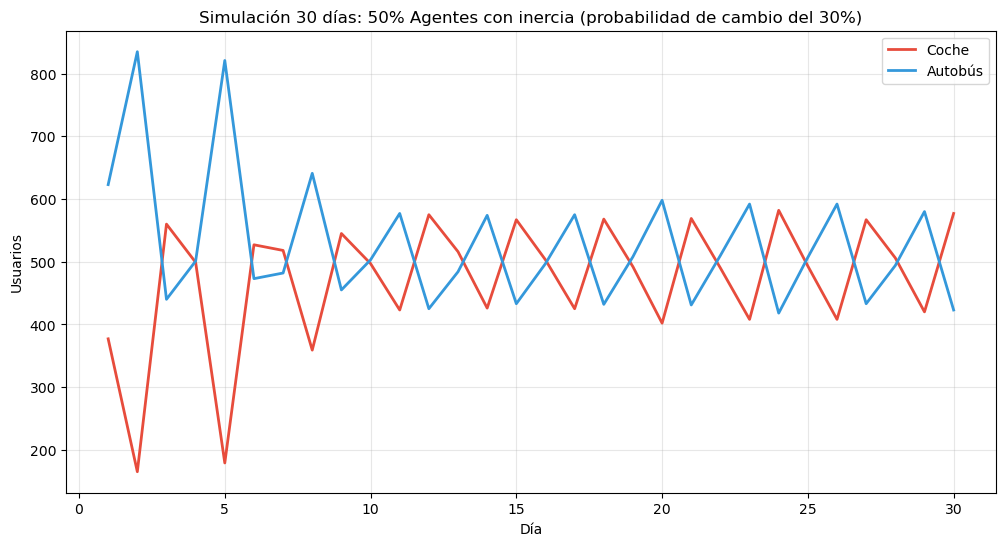

In [5]:
import networkx as nx
import random
import matplotlib.pyplot as plt

#Configuración
N=10
G=nx.grid_2d_graph(N,N)
COSTE_BUS_TRAMO=10 #fixed

for u,v in G.edges():
    G[u][v]['historial']=[]

#people that might change their transport and people that don't
agentes=[]
nodos=list(G.nodes())
for nodo_origen in nodos:
    for i in range(10):
        destino=random.choice(nodos)
        while destino == nodo_origen:
            destino=random.choice(nodos)
        
        #el 50% tiene 'inercia'
        es_inercial=random.random()<0.5
        agentes.append({
            'origen':nodo_origen, 
            'destino':destino, 
            'modo_ayer':None, 
            'es_inercial':es_inercial
        })

def get_coste_bpr(coches):
    return 5*(1+0.15*(coches/8)**4)

#Simulación (30 días)
dias=30
historico_coches=[]
historico_buses=[]

for dia in range(1,dias+1):
    for u,v in G.edges():
        G[u][v]['cars_count_hoy']=0
    random.shuffle(agentes)
    conteo_coche=0 
    conteo_bus=0
    
    for a in agentes:
        #memoria de 2 días, con la que calculamos el coste
        if dia == 1:
            ruta=nx.shortest_path(G,a['origen'],a['destino'], 
                                    weight=lambda u,v,d: get_coste_bpr(d['cars_count_hoy']))
            coste_coche_percibido=sum([get_coste_bpr(G[u][v]['cars_count_hoy']) 
                                         for u,v in zip(ruta[:-1],ruta[1:])])
        else:
            def peso_memoria_2dias(u,v,d):
                hist=d['historial']
                return (hist[-1]+hist[-2])/2 if len(hist) >= 2 else hist[-1]

            ruta=nx.shortest_path(G, a['origen'], a['destino'], weight=peso_memoria_2dias)
            coste_coche_percibido=sum([peso_memoria_2dias(u,v, G[u][v]) 
                                         for u,v in zip(ruta[:-1], ruta[1:])])

        distancia=nx.shortest_path_length(G,a['origen'],a['destino'])
        coste_bus=distancia*COSTE_BUS_TRAMO
        
        #LÓGICA DE DECISIÓN CON PROBABILIDAD/INERCIA
        mejor_modo='coche' if coste_coche_percibido <= coste_bus else 'bus'
        
        decision_final=mejor_modo
        
        #Si el agente va con inercia y ya tiene un modo previo, hay probabilidad de que NO cambie
        if a['es_inercial'] and a['modo_ayer'] is not None:
            #si la mejor opción es distinta a la de ayer, solo cambia con un 30% de prob. (Es decir, hay un 70% de probabilidad de que se quede como está por inercia)
            if mejor_modo!=a['modo_ayer']:
                if random.random() > 0.3: # 0.3 es la probabilidad de cambio
                    decision_final=a['modo_ayer']

        # Ejecutar decisión
        if decision_final == 'coche':
            conteo_coche+=1
            for i in range(len(ruta)-1):
                G[ruta[i]][ruta[i+1]]['cars_count_hoy']+=1
        else:
            conteo_bus+=1
        
        a['modo_ayer']=decision_final

    #actualizamos el historial
    for u, v in G.edges():
        G[u][v]['historial'].append(get_coste_bpr(G[u][v]['cars_count_hoy']))

    historico_coches.append(conteo_coche)
    historico_buses.append(conteo_bus)
    print(f"Día {dia}: Coche = {conteo_coche} | Bus = {conteo_bus}")

#Gráfico
plt.figure(figsize=(12, 6))
plt.plot(range(1,dias+1),historico_coches,label="Coche",color='#e74c3c',linewidth=2)
plt.plot(range(1,dias+1),historico_buses,label="Autobús",color='#3498db',linewidth=2)
plt.title("Simulación 30 días: 50% Agentes con inercia (probabilidad de cambio del 30%)")
plt.xlabel("Día")
plt.ylabel("Usuarios")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()